#Goals of this Notebook:
1) Data Analysis
2) Train a Decision Tree Classifier to predict Mortality

#Part 1. Data Analysis

In [22]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/NYC_Motor_Vehicle_Collisions_to_Person.csv')



In [23]:
def is_valid_test(expected_counts):
  num_gte_five = 0
  num_cells = 0
  for row in expected_counts:
    for cell in row:
      if cell >= 5:
        num_gte_five += 1
      num_cells += 1
  print(f"Chi-Squared test validity: {num_gte_five/num_cells > 0.8}, Value: {num_gte_five/num_cells}")
def chi_square_test (col1, col2):
  contingency_table = pd.crosstab(col1, col2)
  chi2_statistic, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

  cramers_v = association(contingency_table, method="cramer")
  is_valid_test(expected_frequencies)
  print(f"Chi-square statistic: {chi2_statistic}")
  print(f"P-Value: {p_value}")
  print(f"Degrees of Freedom: {dof}")
  print(f"Expected Frequencies: {expected_frequencies}")
  print(f"Cramer\'s V test for effect size {cramers_v}")

In [ ]:
#Chi-squared test for independence between the variables: Type of Bodily Injury, Mortality
chi_square_test(df["PERSON_INJURY"], df["BODILY_INJURY"])



Code below condenses categories to raise expected frequencies table values to > 5. This makes the chi-square test for independence viable.  


In [ ]:
df['SAFETY_EQUIPMENT'] = df['SAFETY_EQUIPMENT'].apply(
    lambda x:
    'Seat Belt or Harness' if x in [
        "Lap Belt & Harness",
        "Lap Belt",
        "Harness"
    ]

    else 'Seat Belt and Airbag' if x in [
        "Air Bag Deployed/Lap Belt/Harness",
        "Air Bag Deployed/Lap Belt"
    ]

    else 'Airbag Only' if x in [
        "Air Bag Deployed"
    ]

    else 'Child Restraint' if x in [
        "Child Restraint Only",
        "Air Bag Deployed/Child Restraint"
    ]

    else 'Helmet' if x in [
        "Helmet (Motorcycle Only)",
        "Helmet Only (In-Line Skater/Bicyclist)",
        "Helmet/Other (In-Line Skater/Bicyclist)"
    ]


    else 'Other Protective Gear' if x in [
        "Pads Only (In-Line Skater/Bicyclist)",
        "Stoppers Only (In-Line Skater/Bicyclist)"
    ]

    else 'Other/Unknown' if x in [
        "Other",
        "Unknown"
    ]

    else 'Other/Unknown'
)

In [ ]:
#Chi-squared test for independence between the variables: Safety Equipment, Mortality
print(df["SAFETY_EQUIPMENT"].value_counts())
chi_square_test(df["BODILY_INJURY"], df["SAFETY_EQUIPMENT"])

SAFETY_EQUIPMENT
Seat Belt or Harness     21237
Other/Unknown            18726
Helmet                    2561
Seat Belt and Airbag      1038
Child Restraint            296
Airbag Only                247
Other Protective Gear       16
Name: count, dtype: int64
Chi-Squared test validity: True, Value: 0.8095238095238095
Chi-square statistic: 6545.180211198169
P-Value: 0.0
Degrees of Freedom: 66
Expected Frequencies: [[4.52897713e+00 5.42743818e+00 4.69583418e+01 2.93375037e-01
  3.43358809e+02 1.90327055e+01 3.89400354e+02]
 [4.20148002e+01 5.03497201e+01 4.35627139e+02 2.72160649e+00
  3.18530020e+03 1.76564221e+02 3.61242232e+03]
 [9.20910677e+00 1.10360146e+01 9.54838966e+01 5.96541330e-01
  6.98177059e+02 3.87006188e+01 7.91796763e+02]
 [1.96442284e+01 2.35412615e+01 2.03679631e+02 1.27250062e+00
  1.48930292e+03 8.25534779e+01 1.68900598e+03]
 [2.15084427e+01 2.57752997e+01 2.23008590e+02 1.39325945e+00
  1.63063602e+03 9.03877065e+01 1.84929068e+03]
 [5.15038190e-01 6.17211759e-01 5

In [ ]:
#ttest for independence between the variables: Age, Mortality
injured = df[(df['PERSON_INJURY'] == 'Injured')
             & (df['PERSON_AGE'] < 130)
             & (df['PERSON_AGE'] > 0)]['PERSON_AGE'].dropna()
dead = df[(df['PERSON_INJURY'] == 'Killed')
            & (df['PERSON_AGE'] < 130)
            & (df['PERSON_AGE'] > 0)]['PERSON_AGE'].dropna()

print(injured.mean(), injured.std())
print(dead.mean(), dead.std(), '\n')
t_stat, p_val = stats.ttest_ind(injured, dead, equal_var=False, alternative='less')
print(t_stat, p_val)

36.92944094813726 16.318613762297815
46.02978723404255 21.638718808282967 

-6.43716645931239 3.379348852879938e-10


{'whiskers': [<matplotlib.lines.Line2D at 0x7b0d428f8b00>,
 'caps': [<matplotlib.lines.Line2D at 0x7b0d428f90d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b0d428f8860>,
 'medians': [<matplotlib.lines.Line2D at 0x7b0d428f9700>,
 'fliers': [<matplotlib.lines.Line2D at 0x7b0d428f9a00>,
 'means': []}

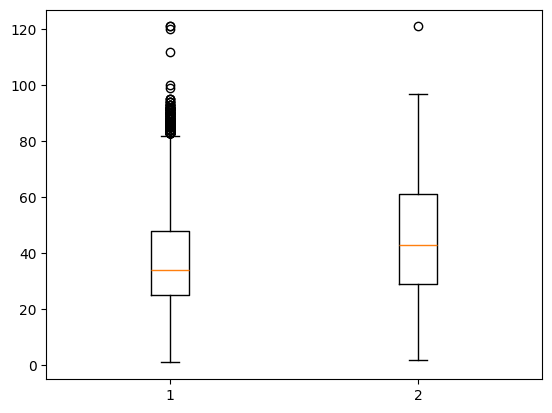

In [ ]:
x = [injured, dead]
plt.boxplot(x, orientation = 'vertical')

Part 2. Classification

Value counts: PERSON_INJURY
0    45416
1      253
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=5. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 1 candidates, totalling 10 fits
Best Params: {'clf__max_depth': 4}
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       2.734472      0.518468          0.36805        0.139018   

   param_clf__max_depth                 params  split0_test_score  \
0                     4  {'clf__max_depth': 4}               0.95   

   split1_test_score  split2_test_score  split3_test_score  split4_test_score  \
0               0.75           0.666667           0.666667           0.857143   

   split5_test_score  split6_test_score  split7_test_score  split8_test_score  \
0               0.75                0.7                0.6               0.75   

   split9_test_score  mean_test_score  std_test_score  rank_test_score  
0               0.75         0.744048        0.094876                1  
Accuracy: 0.9980293409240202
Precision: 0.8636363636363636
Recall: 0.76
DecisionTreeClassifier(max_depth=4)
|--- cat__EMOTIONAL_STATUS_Apparent Death <= 0.50


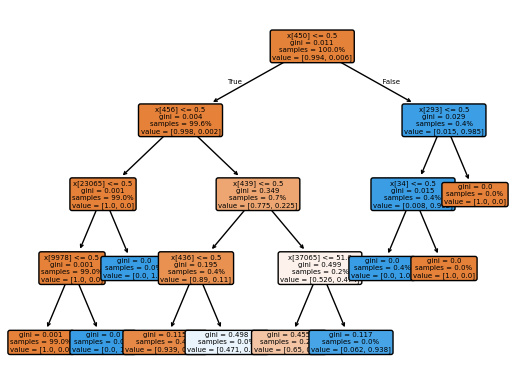

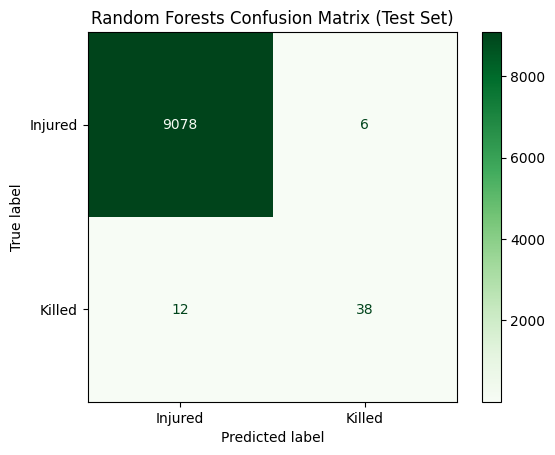

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


df = pd.read_csv("/content/drive/MyDrive/NYC_Motor_Vehicle_Collisions_to_Person.csv")

X = df.drop('PERSON_INJURY', axis=1)
y = df['PERSON_INJURY'].apply(lambda x: 1 if x == 'Killed' else 0)


print(f"Value counts: {y.value_counts()}")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)


#Cleaning '?': Imputation with mode, 'np.nan': Imputation with median
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
   X_train[col] = X_train[col].replace("?", X_train[col].mode()[0])
   X_test[col] = X_test[col].replace("?", X_train[col].mode()[0])
numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()
for col in numerical_cols:
   X_train[col] = X_train[col].fillna(X_train[col].median())
   X_test[col] = X_test[col].fillna(X_train[col].median())


#One hot encoding
preprocessor = ColumnTransformer(
   transformers=[
       ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
   ],
   remainder="passthrough"
)
pipeline = Pipeline(steps=[
   ("preprocessor", preprocessor),
   ("clf", tree.DecisionTreeClassifier())
])
####


#Training


param_grid = {
   #'clf__n_estimators': [10, 50],
   'clf__max_depth': [4],
   #'clf__min_samples_leaf': [1, 2, 3, 4],
}
rs = RandomizedSearchCV(estimator=pipeline, param_distributions=param_grid,
n_iter=5, cv=10, verbose=2, n_jobs=-1, scoring="recall")


rs.fit(X_train, y_train)


results_df = pd.DataFrame(rs.cv_results_)
print("Best Params:", rs.best_params_)
print(results_df)
######


#Final Test & eval
y_pred = rs.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

#Display results
print(rs.best_estimator_.named_steps['clf'])

best_pipeline = rs.best_estimator_
preprocessor = best_pipeline.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
tree_model = best_pipeline.named_steps['clf']

tree.plot_tree(rs.best_estimator_.named_steps['clf'],
               filled=True, proportion=True, rounded=True,
               fontsize=5)
print(export_text(tree_model, feature_names=list(feature_names)))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels
                             =["Injured", "Killed"])
disp.plot(cmap=plt.cm.Greens)
plt.title("Random Forests Confusion Matrix (Test Set)")
plt.show()